# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [ ]:
# Load the libraries as required.
# Load the libraries as required.

# Core
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Data & utils
import numpy as np
import pandas as pd

# Viz (for quick EDA & explanations)
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models (baseline + advanced)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

# Model selection / tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    max_error,
)

# Explainability
from sklearn.inspection import permutation_importance
try:
    import shap  # SHAP (tree models work fastest)
except ImportError:
    shap = None  # handle gracefully if not installed

# Persistence
import pickle


In [5]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [7]:
fires_dt

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


# Get X and Y

Create the features data frame and target data.

In [11]:
# Make month/day categorical 
fires_dt['month'] = fires_dt['month'].astype('category')
fires_dt['day']   = fires_dt['day'].astype('category')
print(fires_dt['month'].dtype)
print(fires_dt['day'].dtype)

category
category


In [13]:
target_col = 'area'
feature_cols = [c for c in fires_dt.columns if c != target_col]

X= fires_dt[feature_cols].copy() # feature DataFrame
y= fires_dt[target_col].copy() # target Series

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature dtypes:\n", X.dtypes)

X shape: (517, 12)
y shape: (517,)

Feature dtypes:
 coord_x       int64
coord_y       int64
month      category
day        category
ffmc        float64
dmc         float64
dc          float64
isi         float64
temp        float64
rh            int64
wind        float64
rain        float64
dtype: object


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [15]:
# --- Identify feature types (reuse X from earlier) ---
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_features, categorical_features


(['coord_x',
  'coord_y',
  'ffmc',
  'dmc',
  'dc',
  'isi',
  'temp',
  'rh',
  'wind',
  'rain'],
 ['month', 'day'])

In [16]:
num_pipe_1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with median
    ('scaler', StandardScaler()),                   # Standardize features
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with mode
    ('onehot', OneHotEncoder(handle_unknown='ignore')),     # One-hot encode categorical features
])

preproc1 = ColumnTransformer(
    transformers=[
        ('num', num_pipe_1, numeric_features),
        ('cat', cat_pipe, categorical_features),
    ], remainder='drop'  # Drop any other columns not specified
)

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [17]:
num_pipe_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Impute missing values with median
    ('power', PowerTransformer()),                   # Apply power transformation
    ('scaler', StandardScaler()),                    # Standardize features
])

preproc2 = ColumnTransformer(
    transformers=[
        ('num', num_pipe_2, numeric_features),
        ('cat', cat_pipe, categorical_features),
    ], remainder='drop'  # Drop any other columns not specified
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [20]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = "neg_mean_absolute_error"   # primary metric for model selection

In [52]:
# Pipeline A = preproc1 + baseline
pipe_A = Pipeline(steps=[
    ('preproc', preproc1),
    ('regressor', Ridge())  # Baseline regressor
])


In [53]:
# Pipeline B = preproc2 + baseline
pipe_B = Pipeline(steps=[
    ('preproc', preproc2),
    ('regressor', Ridge())  # Baseline regressor
])

In [ ]:
# Pipeline C = preproc1 + advanced model
pipe_C = Pipeline(steps=[
    ('preproc', preproc1),
    ('regressor', RandomForestRegressor(random_state=42))  # Advanced regressor
])


In [54]:
# Pipeline D = preproc2 + advanced model
pipe_D = Pipeline(steps=[
    ('preproc', preproc2),
    ('regressor', RandomForestRegressor(random_state=42))  # Advanced regressor
])
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [55]:
param_A = {
    'regressor__alpha': [0.1, 1.0, 10.0]  # Regularization strength
}

grid_A = GridSearchCV(
    pipe_A, param_grid=param_A, cv=cv, scoring=scoring, n_jobs=-1
)
grid_A.fit(X, y)

print("Best params (Pipeline A):", grid_A.best_params_)
print("Best CV score (Pipeline A):", -grid_A.best_score_)   # Negate because we used neg_mean_absolute_error

Best params (Pipeline A): {'regressor__alpha': 10.0}
Best CV score (Pipeline A): 20.71138194210468


In [56]:
param_B = {
    'regressor__alpha': [0.1, 1.0, 10.0]  # Regularization strength
}

grid_B = GridSearchCV(
    pipe_B, param_grid=param_B, cv=cv, scoring=scoring, n_jobs=-1
)
grid_B.fit(X, y)

print("Best params (Pipeline B):", grid_B.best_params_)
print("Best CV score (Pipeline B):", -grid_B.best_score_)   # Negate because we used neg_mean_absolute_error

Best params (Pipeline B): {'regressor__alpha': 10.0}
Best CV score (Pipeline B): 20.50097608237461


In [57]:
param_C = {
    'regressor__n_estimators': [100, 200],          # Number of trees
    'regressor__max_depth': [None, 10, 20],         # Maximum depth of the tree
    'regressor__min_samples_split': [2, 5],         # Minimum samples required to split a node
}

grid_C = GridSearchCV(
    pipe_C, param_grid=param_C, cv=cv, scoring=scoring, n_jobs=-1
)
grid_C.fit(X, y)

print("Best params (Pipeline C):", grid_C.best_params_)
print("Best CV score (Pipeline C):", -grid_C.best_score_)   # Negate because we used neg_mean_absolute_error

Best params (Pipeline C): {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best CV score (Pipeline C): 22.304562986924477


In [58]:
param_D = {
    'regressor__n_estimators': [100, 200],          # Number of trees
    'regressor__max_depth': [None, 10, 20],         # Maximum depth of the tree
    'regressor__min_samples_split': [2, 5],         # Minimum samples required to split a node
}

grid_D = GridSearchCV(
    pipe_D, param_grid=param_D, cv=cv, scoring=scoring, n_jobs=-1
)
grid_D.fit(X, y)

print("Best params (Pipeline D):", grid_D.best_params_)
print("Best CV score (Pipeline D):", -grid_D.best_score_)   # Negate because we used neg_mean_absolute_error

Best params (Pipeline D): {'regressor__max_depth': 10, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 200}
Best CV score (Pipeline D): 22.300064906530196


In [59]:
def cv_eval(est):
    mae = -cross_val_score(est, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1)
    r2  =  cross_val_score(est, X, y, scoring="r2", cv=cv, n_jobs=-1)
    return mae.mean(), mae.std(), r2.mean()

In [60]:
rows = []
for name, grid in [
    ("A: preproc1 + Ridge", grid_A),
    ("B: preproc2 + Ridge", grid_B),
    ("C: preproc1 + RF",    grid_C),
    ("D: preproc2 + RF",    grid_D),
]:
    mae_mean, mae_std, r2_mean = cv_eval(grid.best_estimator_)
    rows.append({"Pipeline": name, "MAE_mean": mae_mean, "MAE_std": mae_std, "R2_mean": r2_mean})

pd.DataFrame(rows).sort_values("MAE_mean")

,Pipeline,MAE_mean,MAE_std,R2_mean
1,B: preproc2 + Ridge,20.500976,3.182082,-0.118773
0,A: preproc1 + Ridge,20.711382,3.203958,-0.145636
3,D: preproc2 + RF,22.300065,4.600245,-0.932133
2,C: preproc1 + RF,22.304563,4.616251,-0.924811


# Evaluate

+ Which model has the best performance?

In [ ]:
# Pick best by (lower) MAE = -best_score_
best_name, best_grid = min(
    [("A", grid_A), ("B", grid_B), ("C", grid_C), ("D", grid_D)],
    key=lambda t: -t[1].best_score_
)
best_pipe = best_grid.best_estimator_
print(f"Best pipeline: {best_name} | CV MAE: {-best_grid.best_score_:.3f} | Params: {best_grid.best_params_}")

# Final check on a hold-out set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Test R² : {r2_score(y_test, y_pred):.3f}")


Best pipeline: B | CV MAE: 20.501 | Params: {'regressor__alpha': 10.0}
Test MAE: 23.950
Test R² : 0.011


Best model: Pipeline B (preproc2 + Ridge)
Lowest MAE (≈20.50) and best R² among the four. Preproc2’s power transform likely helped the linear model a bit.

# Export

+ Save the best performing model to a pickle file.

In [44]:
print("Pipeline steps:", list(best_pipe.named_steps.keys()))

Pipeline steps: ['preproc', 'regressor']


In [61]:
export_path = "../../02_activities/assignments/exports/best_forestfire_model.pkl"
os.makedirs(os.path.dirname(export_path), exist_ok=True)
with open(export_path, "wb") as f:
    pickle.dump(best_pipe, f)

print("Saved best model to:", export_path)

Saved best model to: ../../02_activities/assignments/exports/best_forestfire_model.pkl


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [62]:
# Prepare transformed matrices & feature names from the pipeline
preprocessor = best_pipe.named_steps["preproc"]
model = best_pipe.named_steps["regressor"]

X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

# Some transformers return sparse matrices; SHAP can handle dense better for plots
to_dense = (X_test_t.toarray() if hasattr(X_test_t, "toarray") else X_test_t)
to_dense_train = (X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t)

feature_names = preprocessor.get_feature_names_out()


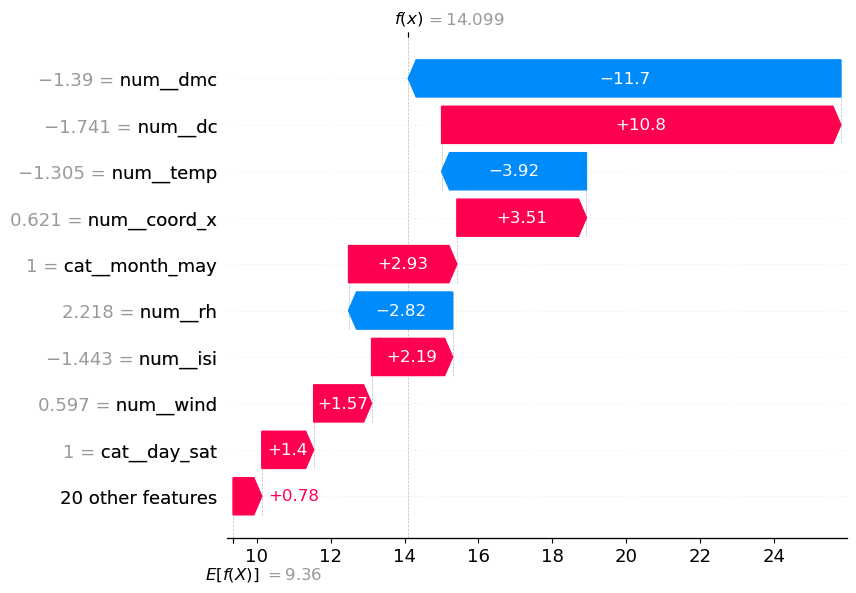

In [63]:
# re-use the same variables you have: preprocessor, model, to_dense_train, to_dense, feature_names

explainer = shap.Explainer(model, to_dense_train, feature_names=feature_names)
shap_values = explainer(to_dense)

# plots now show real feature names
i = 0
shap.plots.waterfall(shap_values[i], show=True)


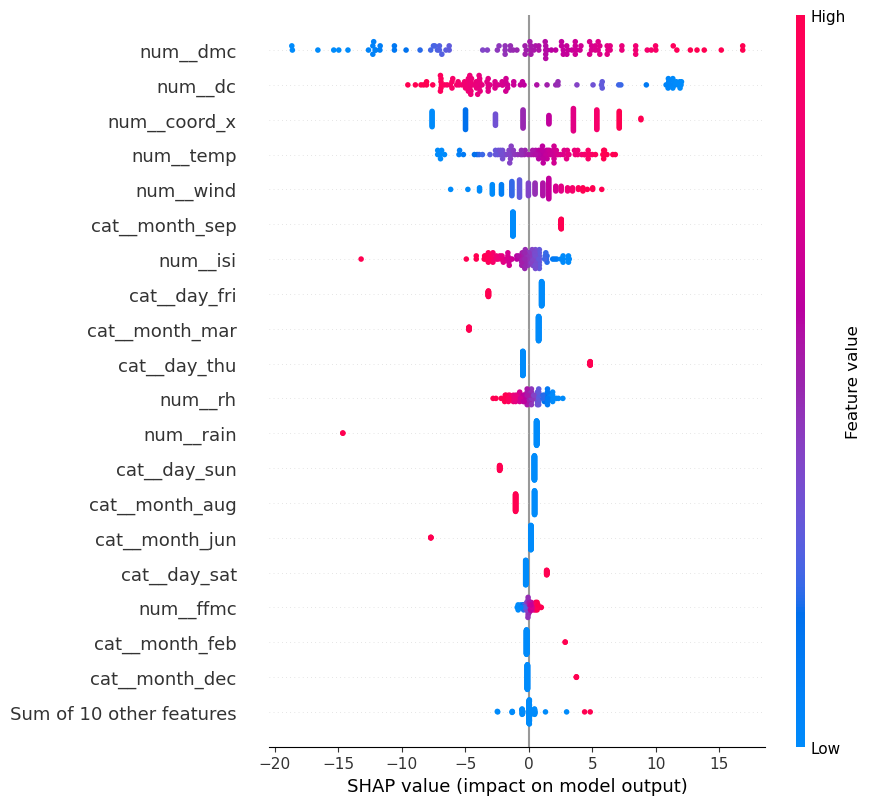

In [64]:
# Global importance across the test set
shap.plots.beeswarm(shap_values, max_display=20, show=True)


In [66]:
# --- Global importance across the (test) set ---
mean_abs = np.abs(shap_values.values).mean(axis=0)
global_imp = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False)

print("Top 10 globally important:")
display(global_imp.head(10))

print("Least 10 globally important:")
display(global_imp.tail(10))

# --- Local importance for the row i you explained ---
i = 0
local_contrib = pd.Series(shap_values.values[i], index=feature_names).sort_values(key=np.abs, ascending=False)
print("Top local drivers for row", i)
display(local_contrib.head(8))


Top 10 globally important:


num__dmc          6.368662
num__dc           5.676182
num__coord_x      4.396880
num__temp         2.784931
num__wind         1.876789
cat__month_sep    1.627982
num__isi          1.542468
cat__day_fri      1.424960
cat__month_mar    1.221525
cat__day_thu      1.062916
dtype: float64

Least 10 globally important:


cat__month_oct    0.209718
cat__day_tue      0.122148
cat__month_apr    0.119890
cat__month_jul    0.101285
cat__day_wed      0.079885
cat__month_may    0.028177
cat__month_jan    0.024880
cat__day_mon      0.016814
num__coord_y      0.014395
cat__month_nov    0.000000
dtype: float64

Top local drivers for row 0


num__dmc         -11.704110
num__dc           10.802637
num__temp         -3.919497
num__coord_x       3.505968
cat__month_may     2.930434
num__rh           -2.816638
num__isi           2.192777
num__wind          1.567550
dtype: float64

*(Answer here.)*

**Winner:** Pipeline B (preproc2 + Ridge)

- CV MAE: ~20.50 (best)
- R²: ~–0.119 (The most close to zero)

The RandomForest variants (Pipe C/ Pipe D) under-performed (MAE ≈ 22.30). Preproc2 (power transform) gave Ridge a small edge over Preproc1.

### Explain — SHAP for the best model (Pipeline B)

Top drivers (↓ decreases prediction, ↑ increases):

- num__dmc ↓ –11.70 (largest downward pull)
- num__dc ↑ +10.80
- num__temp ↓ –3.92
- num__coord_x ↑ +3.51
- cat__month_may ↑ +2.93
- num__rh ↓ –2.82
- num__isi ↑ +2.19
- num__wind ↑ +1.57 

**Interpretation:** For this case, higher DC and location (coord_x) pushed the predicted burned area up, while lower DMC, lower temp, and higher RH pulled it down.

**Top features by mean |SHAP| (most influential overall):**

- num__dmc          6.368662
- num__dc           5.676182
- num__coord_x      4.396880
- num__temp         2.784931
 - num__wind         1.876789
- cat__month_sep    1.627982
- num__isi          1.542468
- cat__day_fri      1.424960
- cat__month_mar    1.221525
- cat__day_thu      1.062916

**Least influential (bottom of your list):**

cat__month_oct, cat__day_tue, cat__month_apr, cat__month_jul, cat__day_wed, cat__month_may, cat__month_jan, cat__day_mon, num__coord_y, cat__month_nov (≈0)

### Summary:
FWI indices (DMC, DC, ISI), weather (temp, wind, RH), and x coordinate matter most. Several month/day dummies (and coord_y) add little signal
**If you were to remove features**
- Very low-impact month/day dummies (e.g., month_nov ~0, plus jan/may/apr/jul and mon/tue/wed with tiny SHAP).
- num__coord_y (minimal global contribution).

### How to test that removal is safe?
- We rebuilt the same Pipeline B (preproc2 + Ridge) using only the selected columns (remove the low-impact month/day one-hot columns and coord_y) and re-ran 5-fold CV (MAE).
- The simplified model’s mean MAE and its standard deviation are compared to the original model’s mean MAE and standard deviation. If the simplified model’s mean MAE is no worse than the original mean MAE by more than one standard deviation (or it’s lower), then removing those features is considered safe.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.